<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مشارکت در کلاس
</font>
</h1>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین نرخ مشارکت دانشجویان یک دوره‌ی آموزشی آنلاین در قالب یک فایل csv به شما داده شده است.
نرخ مشارکت بیانگر نسبت مدت زمان تماشای ویدئوی آموزشی توسط هر دانشجو به کل مدت زمان آموزش است.
نخست داده‌ها را از فایل 
<code>Engagement_ratio.csv</code>
بخوانید و در متغیر <code>data</code> بریزید.
</font>
</p>

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
data = np.loadtxt('Engagement_ratio.csv')
print(data[0:5])
print(len(data))

[0.00014921 0.03204704 0.07161051 0.1207245  0.00476624]
8702


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش اول
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
میانگین و انحراف از میانگین این جمعیت را حساب کنید.
</font>
</p>

In [4]:
print(f"Maximum: {data.max()}")
print(f"Minimum: {data.min()}")

Maximum: 1.0
Minimum: 2.73e-10


In [5]:
mean_pop = np.mean(data)
std_pop = np.std(data)
print(f"Mean: {round(mean_pop, 3)}")
print(f"Std: {round(std_pop, 3)}")


Mean: 0.077
Std: 0.107




<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
اکنون ۱۰۰۰ مرتبه نمونه‌گیری به اندازه‌ی ۳۰ عدد از جمعیت بگیرید و به سوالاتی که در ادامه پرسیده می‌شود پاسخ دهید. 
</font>
</p>

In [6]:
n_samples = 1000
sample_size = 30

samples_30 = [np.random.choice(data, sample_size, replace=True) for _ in range(n_samples)]

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
میانگین و انحراف از معیار هر ست از نمونه‌ها را محاسبه کرده و در متغیر‌های
<code>mean_sample_set</code>
و
<code>std_sample_set</code>
ذخیره کنید.
</font>
</p>

In [7]:
mean_sample_set_30 = [np.mean(sample) for sample in samples_30]
std_sample_set_30 = [np.std(sample) for sample in samples_30]

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
 هیستوگرام توزیع نمونه‌‌ها در ۱۰ نمونه‌برداری اول را در قالب ۱۰ تصویر رسم نمایید. 

</font>
</p>

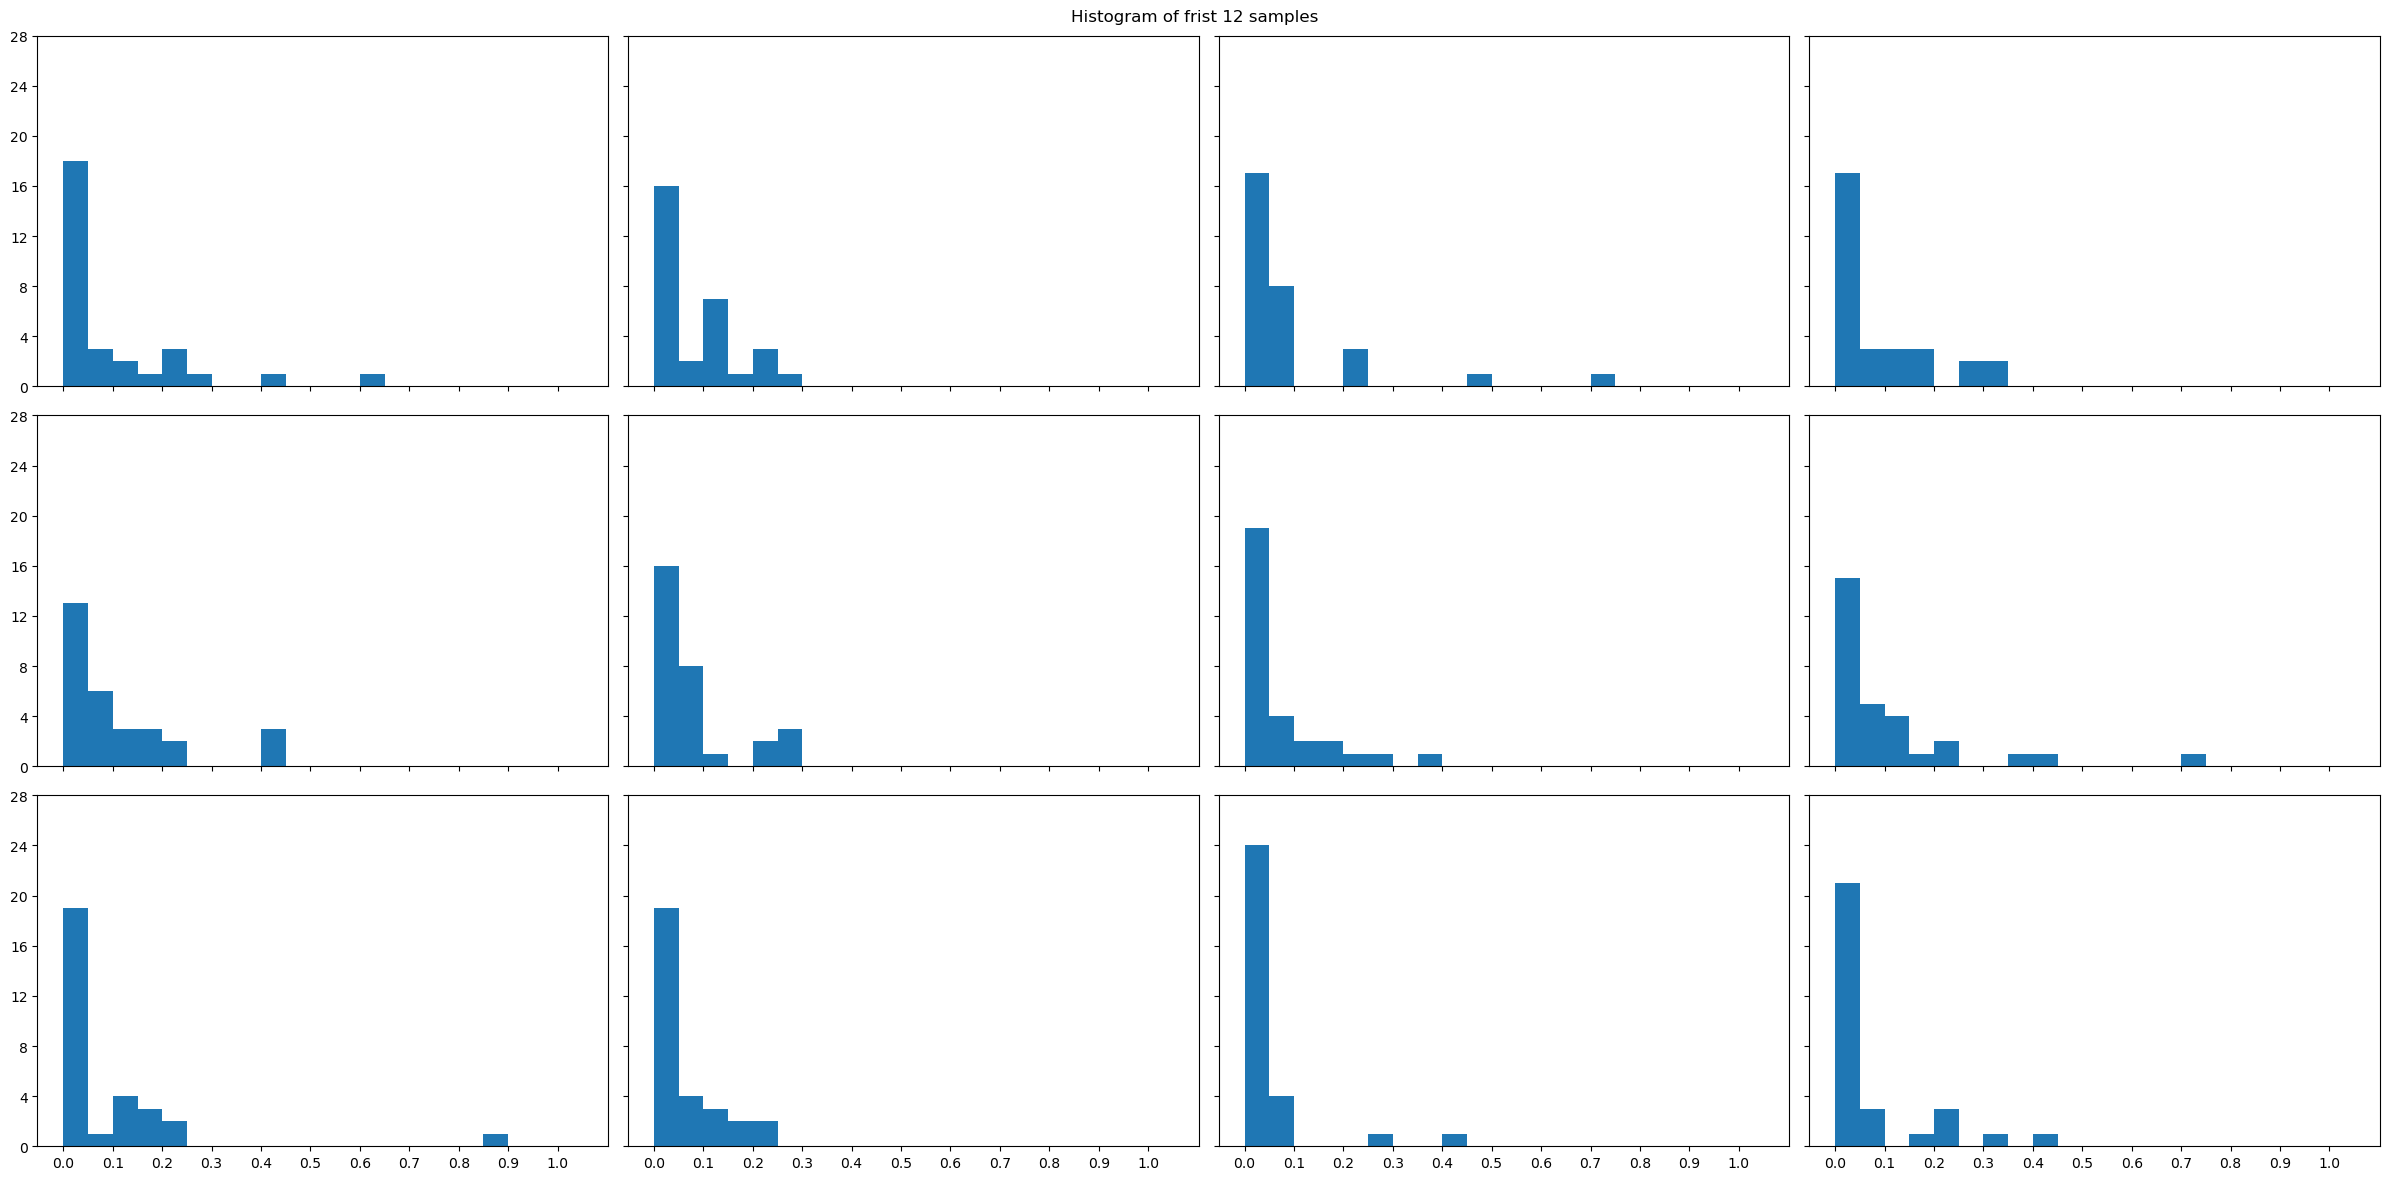

In [8]:
xticks = np.arange(0, 1.1, 0.1)
yticks = np.arange(0,30, 4)
bins = np.arange(0, 1.1, 0.05)

fig, axes = plt.subplots(3, 4, figsize=(24, 12), sharex=True, sharey=True)
fig.suptitle("Histogram of frist 12 samples")
counter = 0
for i in range(3):
    for j in range(4):
        axes[i, j].hist(samples_30[counter], bins=bins)
        axes[i, j].set_xticks(xticks)
        axes[i, j].set_yticks(yticks)
        counter += 1

plt.tight_layout()

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
اکنون هیستوگرام توزیع میانگین تمامی ۱۰۰۰ نمونه‌برداری‌ را در یک تصویر رسم نمایید. آیا تصویر به‌دست آمده قابل پیش‌بینی بود؟
</font>
</p>

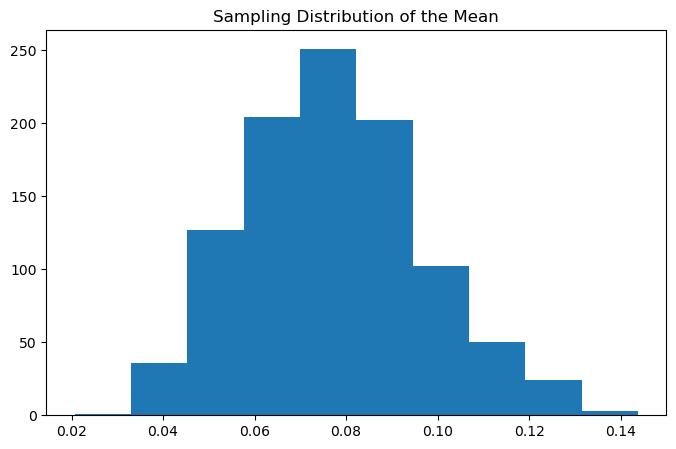

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(mean_sample_set_30)
plt.title("Sampling Distribution of the Mean")
plt.show()

In [ ]:
print("""
    It was expected that the density of the distribution of the mean would also lie roughly within the same range,
    since the density of most samples was between 0 and 0.2.
      """)


    It was expected that the density of the distribution of the mean would also lie roughly within the same range,
    since the density of most samples was between 0 and 0.2.
      




<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تقریبا ۹۵ درصد میانگین نمونه‌ها در چه بازه‌ای قرار می‌گیرد؟ (توجه: این تقریب را بر اساس نرمال فرض کردن توزیع این نمونه‌ها درنظر می‌گیریم.)</font>
</p>

In [28]:
confidence_interval_30 = np.percentile(mean_sample_set_30, [2.5, 97.5])
print(f" 95% of sample means lies in {np.round(confidence_interval_30, 3)}")

 95% of sample means lies in [0.043 0.12 ]



<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بازه‌ی اطمینان ۹۵ درصد در قسمت قبل را با استفاده از z-table محاسبه کنید.
</font>
</p>


In [14]:
def z_confidence_interval(sample_set):
    z_score = 1.96

    mean_sample_means = np.mean(sample_set)
    std_sample_means = np.std(sample_set)
    standard_error = std_sample_means / np.sqrt(len(sample_set))

    upper_bound = mean_sample_means + (z_score * standard_error)
    lower_bound = mean_sample_means - (z_score * standard_error)

    return (lower_bound, upper_bound)


lower_bound, upper_bound = z_confidence_interval(mean_sample_set_30)[0], z_confidence_interval(mean_sample_set_30)[1]
print(f'Interval: {np.round([lower_bound, upper_bound], 3)}')

Interval: [0.076 0.079]


In [ ]:
print("""
    The 95% confidence interval suggests that we are 95% confident that the population mean lies between 0.076 and 0.079 (this range may vary depending on the sample).
      """)

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای هر ۱۰۰۰ نمونه‌گیری صورت گرفته در بالا(بخش اول)، بازه‌ی اطمینان ۹۵ درصد را حساب کنید. درصد تعداد نمونه‌هایی که میانگین جمعیت در بازه‌ی اطمینان ۹۵ درصد آن‌ها(نمونه‌ها) در بازه‌ی بدست آمده بوده‌اند را گزارش کنید.
</font>
</p>


In [17]:
samples_ci_30 = [z_confidence_interval(sample) for sample in samples_30]
samples_mean_set_30 = [np.mean(sample) for sample in samples_30]

In [18]:
counter = 0
for i in range(1000):
    if (samples_ci_30[i][0]< mean_pop <samples_ci_30[i][1]):
        counter += 1

perc = (counter / 1000) * 100
print(f'{perc}% of sample means was in Confidence Interval')

89.2% of sample means was in Confidence Interval


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش دوم
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تمامی خواسته‌های بخش اول را این بار با نمونه‌هایی با اندازه ۲۰۰ سمپل تکرار کنید و نتایج را مقایسه کنید.
</font>
</p>

In [31]:
samples_200 = [np.random.choice(data, 200, replace=True) for _ in range(1000)]

In [32]:
mean_sample_set_200 = [np.mean(sample) for sample in samples_200]
std_sample_set_200 = [np.std(sample) for sample in samples_200]

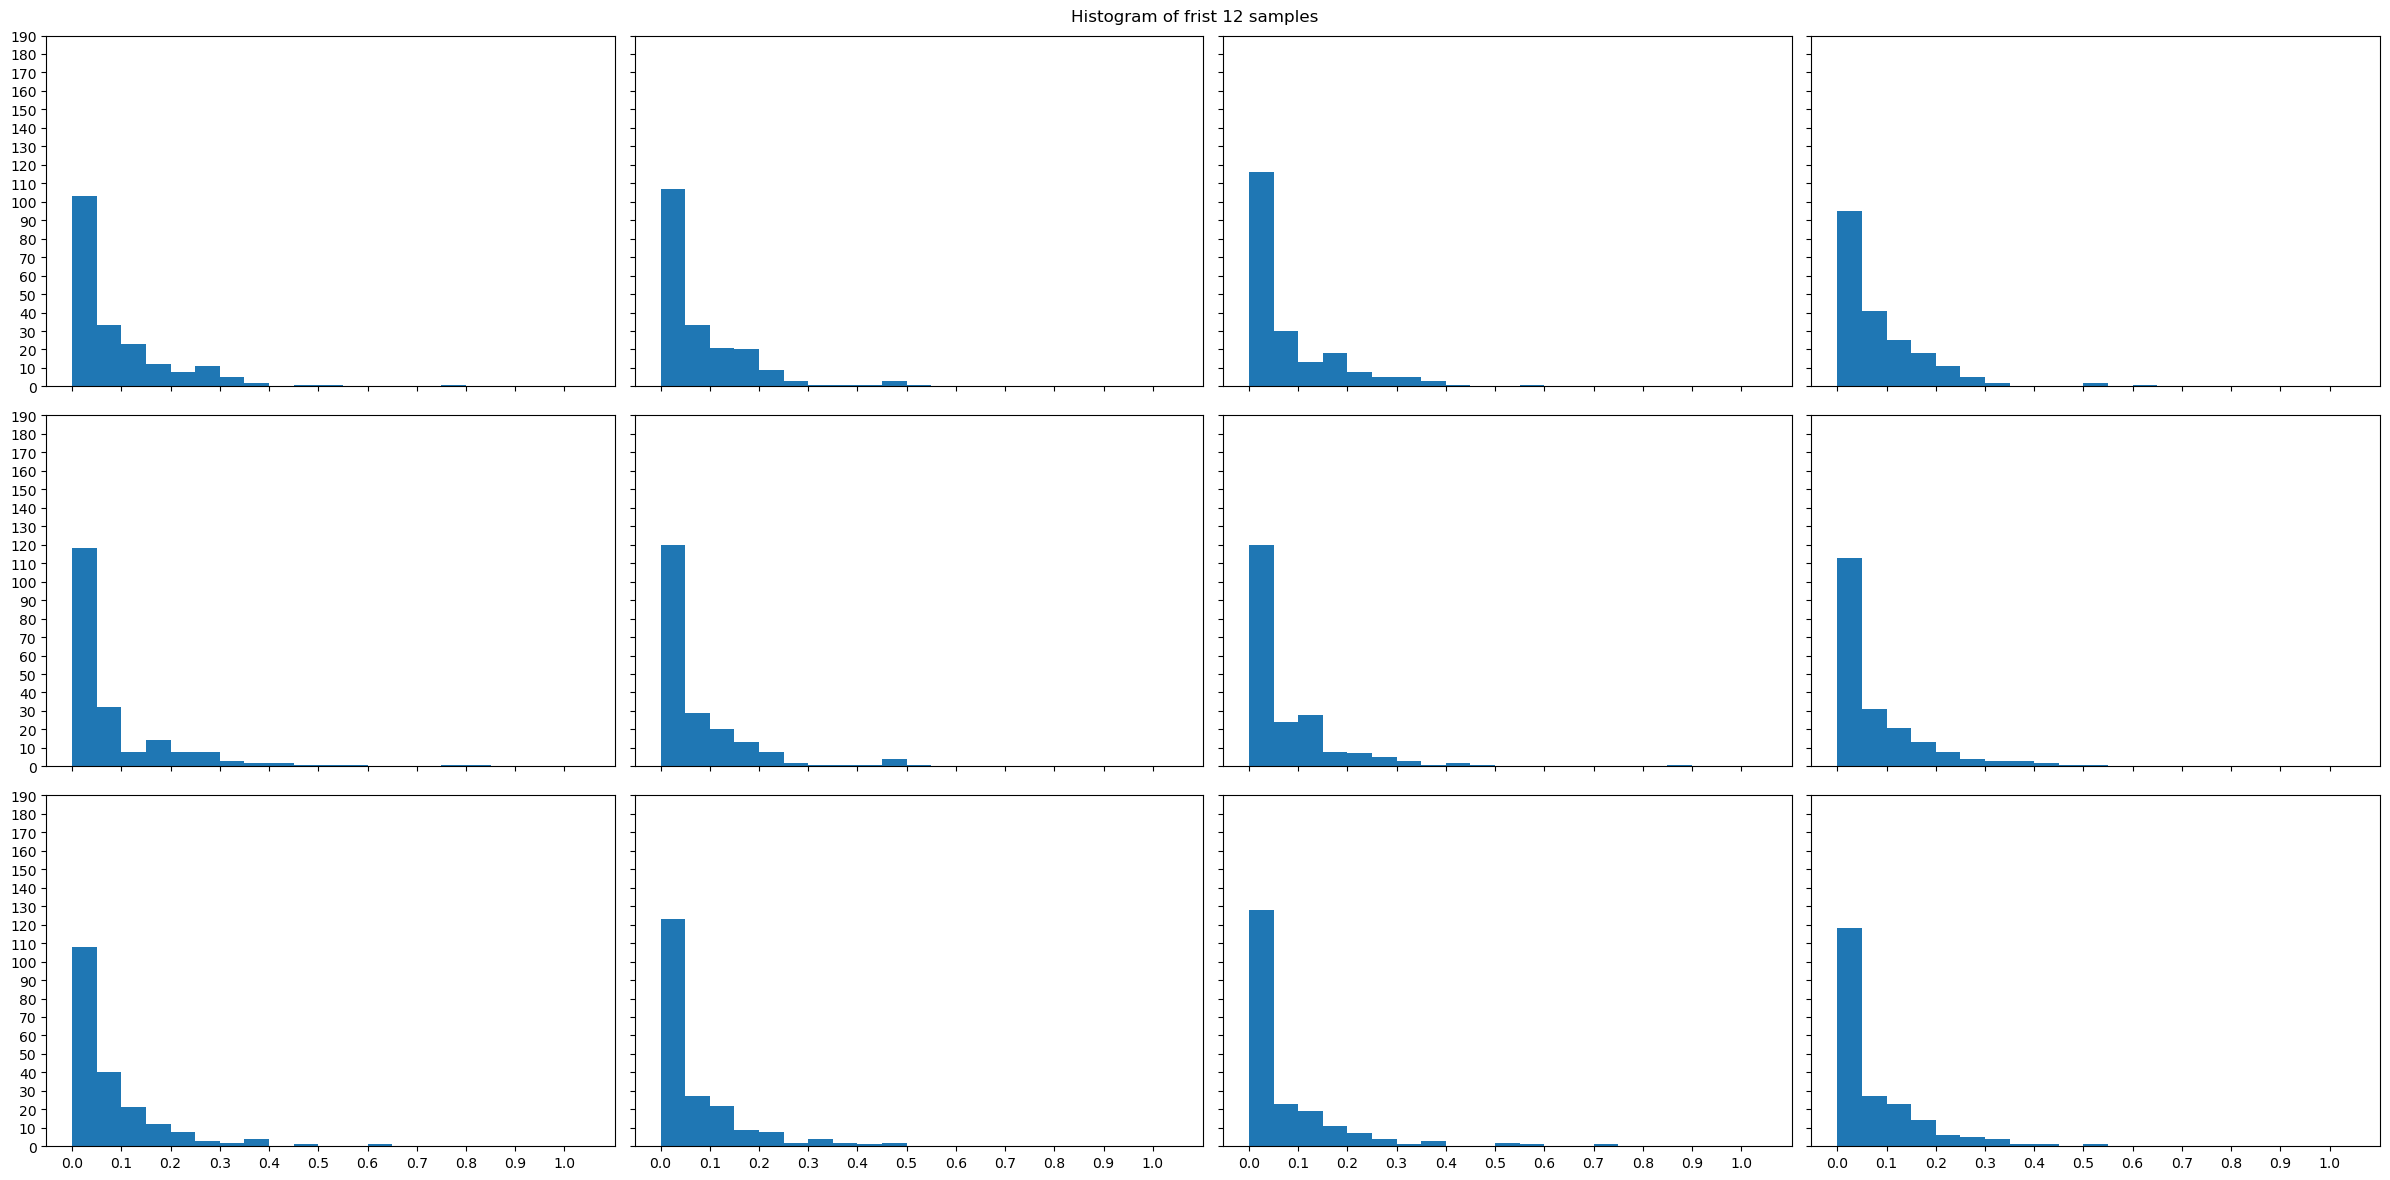

In [33]:
xticks = np.arange(0, 1.1, 0.1)
yticks = np.arange(0,200, 10)
bins = np.arange(0, 1.1, 0.05)

fig, axes = plt.subplots(3, 4, figsize=(24, 12), sharex=True, sharey=True)
fig.suptitle("Histogram of frist 12 samples")
counter = 0
for i in range(3):
    for j in range(4):
        axes[i, j].hist(samples_200[counter], bins=bins)
        axes[i, j].set_xticks(xticks)
        axes[i, j].set_yticks(yticks)
        counter += 1

plt.tight_layout()

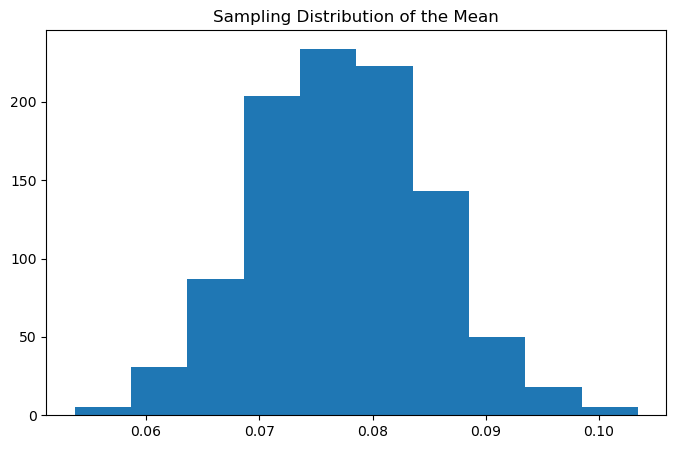

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(mean_sample_set_200)
plt.title("Sampling Distribution of the Mean")
plt.show()

In [35]:
print("""
For samples of size 200,
the distribution of sample means became more normally distributed and more concentrated around the population mean,
as observed in the histograms of the samples and their means.
""")


For samples of size 200,
the distribution of sample means became more normally distributed and more concentrated around the population mean,
as observed in the histograms of the samples and their means.



In [36]:
confidence_interval = np.percentile(mean_sample_set_200, [2.5, 97.5])
print(f" 95% of sample means lies in {np.round(confidence_interval_30, 3)}")


 95% of sample means lies in [0.043 0.12 ]


In [37]:
z_score = 1.96

mean_sample_means_200 = np.mean(mean_sample_set_200)
std_sample_means = np.std(mean_sample_set_200)
standard_error = std_sample_means / np.sqrt(len(mean_sample_set_200))

upper_bound = mean_sample_means_200 + (z_score * standard_error)
lower_bound = mean_sample_means_200 - (z_score * standard_error)

print(f'Interval: {np.round([lower_bound, upper_bound], 3)}')

Interval: [0.077 0.078]


In [38]:
print(stats.skew(data))

2.635002117620648


In [39]:
samples_ci_200 = [z_confidence_interval(sample) for sample in samples_200]
samples_mean_set_200 = [np.mean(sample) for sample in samples_200]

In [40]:
counter = 0
for i in range(1000):
    if (samples_ci_200[i][0]< mean_pop <samples_ci_200[i][1]):
        counter += 1

perc = (counter / 1000) * 100
print(f'{perc}% of sample means was in Confidence Interval')

93.2% of sample means was in Confidence Interval


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش سوم
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
درس جدیدی آماده کرده‌ایم که شامل ۶۰ دقیقه ویدیو است. می‌خواهیم این درس را در دوره‌ی آموزشی دانشجویان بگنجانیم. اما در این درس تغییر استراتژی داده‌ایم و می‌خواهیم ببینیم این تغییر نرخ مشارکت را بیشتر می‌کند یا نه. 
به ۲۰ دانشجو آن را عرضه کرده‌ایم و میانگین نرخ مشارکت آن‌ها ۰.۱۳ بود. 
اگر بخواهیم این درس را برای همه دانشجویان این جمعیت آماده کنیم، برآورد نقطه‌ای و بازه‌ای شما برای نرخ مشارکت دانشجویان بر اساس نمونه‌ای با اندازه‌ی ۲۰ چقدر است؟ پاسخ شما باید برای حداقل ۹۸ درصد جمعیت معتبر باشد.
</font>
</p>

In [44]:
print("Point Estimation is Equal to Mean of this Sample: 0.13")

Point Estimation is Equal to Mean of this Sample: 0.13


In [49]:
std_pop

np.float64(0.10720956480669144)

In [46]:
n = 20 # sample count
sample_mean = 0.13
z = 2.33 # z-score from z-table for 98% confidence level

e = z * (std_pop / np.sqrt(n))

lower = sample_mean - e
upper = sample_mean + e

print(f'Interval: {np.round([lower, upper], 3)}')


Interval: [0.074 0.186]



<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
با توجه به این بررسی‌ها، آیا می‌توانیم ادعا کنیم که تغییر استراتژی ما در ارایه این درس، نرخ مشارکت را بیشتر می‌کند؟

</font>
</p>

In [50]:
print("""Since the baseline participation rate (0.077) lies within the 98% confidence interval [0.074,0.186],
      we do not have sufficient evidence to conclude that the new lesson improves student engagement.""")

Since the baseline participation rate (0.077) lies within the 98% confidence interval [0.074,0.186],
      we do not have sufficient evidence to conclude that the new lesson improves student engagement.
